# Evaluación y Comparación de Modelos MISR

En este notebook nos enfocamos exclusivamente en la **evaluación y análisis visual** de los resultados obtenidos tras el entrenamiento del modelo. 

Asumimos que la fase de entrenamiento ya fue ejecutada (ya sea a través de `run_comparison.py` o `training_step_by_step.ipynb`) y que disponemos del archivo generado `comparison_results.csv`.

A partir de este archivo, calcularemos métricas globales (RMSE, MAE, $R^2$) y generaremos gráficas para comparar el desempeño del modelo **MISR (Ours)** contra el modelo base **SR (nuclearpy)**.

## 1. Importación de Librerías y Carga de Resultados

Comenzamos cargando las herramientas de análisis de datos y graficación, así como los resultados guardados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
print("Librerías listas.")

Librerías listas.


In [2]:
csv_path = "comparison_results.csv"
try:
    df_results = pd.read_csv(csv_path)
    print(f"Se cargaron {len(df_results)} registros desde {csv_path}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{csv_path}'.")
    print("Por favor, ejecuta primero la rutina de entrenamiento para generar los resultados.")
    df_results = pd.DataFrame() # DataFrame vacío por seguridad

if not df_results.empty:
    display(df_results.head())

Se cargaron 274 registros desde comparison_results.csv


,N,Z,A,True_BE_MeV,MISR_Pred_MeV,MISR_Error,Base_SR_Pred_MeV,Base_SR_Error
0,39,41,80,652.080000,656.129100,-4.049100,651.444961,0.635039
1,25,18,43,364.994243,371.086203,-6.091961,366.485743,-1.491501
2,49,49,98,806.540000,831.683151,-25.143151,807.187756,-0.647756
3,28,30,58,486.964909,483.831269,3.133640,486.574278,0.390630
4,38,30,68,595.386376,585.990227,9.396149,596.555337,-1.168961


## 2. Análisis de Métricas (RMSE, MAE, $R^2$)

A continuación, extraemos las columnas de la verdad base y de cada predicción para evaluar estadísticamente cuál modelo comete menos error.

In [3]:
def calc_metrics(y_t, y_p):
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    r2 = r2_score(y_t, y_p)
    return rmse, mae, r2

if not df_results.empty:
    y_true = df_results['True_BE_MeV'].values
    y_pred_misr = df_results['MISR_Pred_MeV'].values
    y_pred_base = df_results['Base_SR_Pred_MeV'].values
    
    rmse_m, mae_m, r2_m = calc_metrics(y_true, y_pred_misr)
    rmse_b, mae_b, r2_b = calc_metrics(y_true, y_pred_base)
    
    print(f"--- COMPARISON RESULTS ---")
    print(f"Number of test samples (Z in [12, 50]): {len(y_true)}")
    print(f"\nMISR Model (Ours):")
    print(f"RMSE: {rmse_m:.4f} MeV")
    print(f"MAE:  {mae_m:.4f} MeV")
    print(f"R^2:  {r2_m:.4f}")
    
    print(f"\nBase SR Model (nuclearpy):")
    print(f"RMSE: {rmse_b:.4f} MeV")
    print(f"MAE:  {mae_b:.4f} MeV")
    print(f"R^2:  {r2_b:.4f}")

--- COMPARISON RESULTS ---
Number of test samples (Z in [12, 50]): 274

MISR Model (Ours):
RMSE: 5.5394 MeV
MAE:  3.9771 MeV
R^2:  0.9994

Base SR Model (nuclearpy):
RMSE: 1.0585 MeV
MAE:  0.8295 MeV
R^2:  1.0000


## 3. Visualización de Resultados

Las gráficas nos permiten entender cómo se comportan los modelos a lo largo del espectro de masas (A) y la morfología del error residual.

- **Scatter Plot:** Energía Real vs Energía Predicha (idealmente sobre la línea $x=y$).
- **KDE Plot:** Densidad de los errores. Una distribución más angosta y centrada en 0 indica mejor precisión.
- **Error a lo largo de A (Número Másico):** Para identificar si existen sesgos sistemáticos en núcleos pesados o ligeros en la submuestra de prueba.

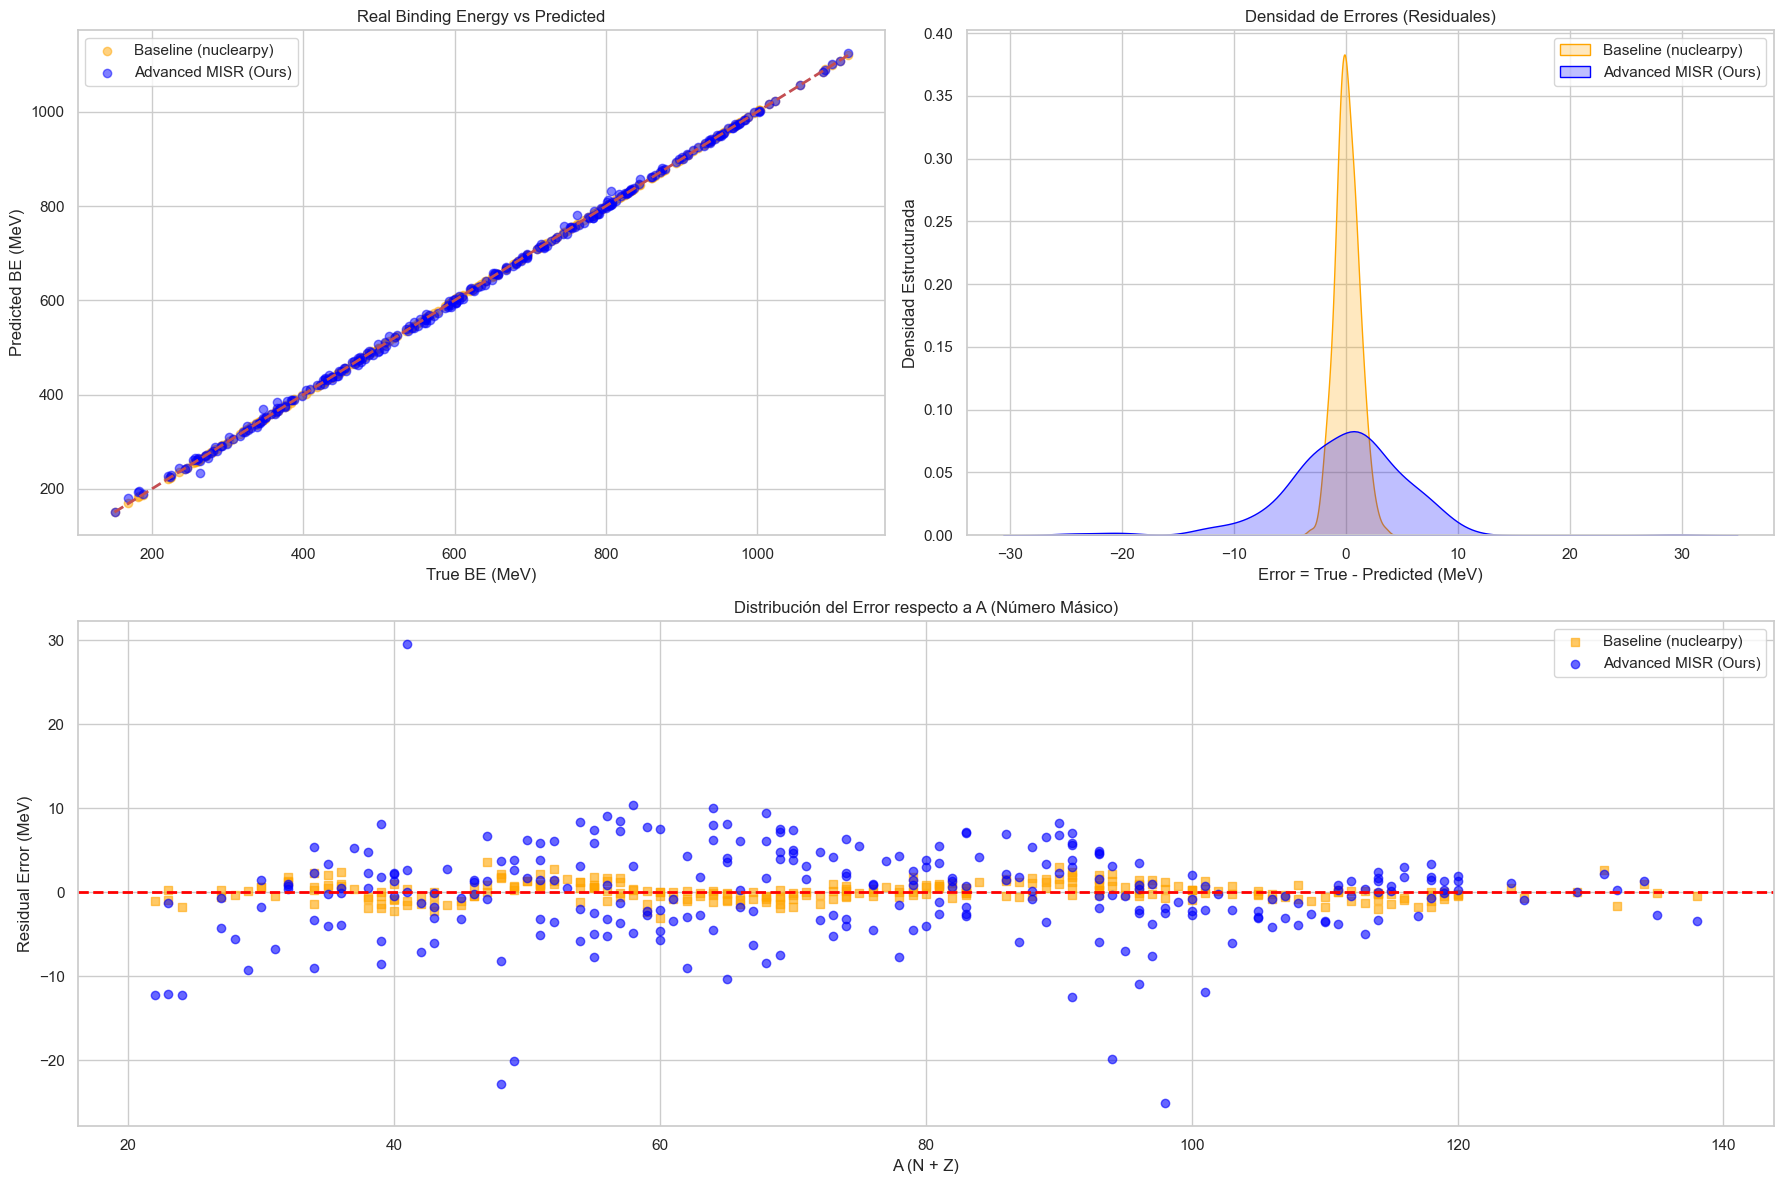

In [4]:
if not df_results.empty:
    # Preparar errores
    errors_base = df_results['Base_SR_Error'].values
    errors_adv = df_results['MISR_Error'].values

    fig = plt.figure(figsize=(18, 12))
    
    # 1. Real vs Predicción
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.scatter(y_true, y_pred_base, alpha=0.5, label='Baseline (nuclearpy)', color='orange')
    ax1.scatter(y_true, y_pred_misr, alpha=0.5, label='Advanced MISR (Ours)', color='blue')
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax1.set_title('Real Binding Energy vs Predicted')
    ax1.set_xlabel('True BE (MeV)')
    ax1.set_ylabel('Predicted BE (MeV)')
    ax1.legend()

    # 2. Distribución de Errores Residuales (KDE Plot)
    ax2 = fig.add_subplot(2, 2, 2)
    sns.kdeplot(errors_base, ax=ax2, label='Baseline (nuclearpy)', fill=True, color='orange')
    sns.kdeplot(errors_adv, ax=ax2, label='Advanced MISR (Ours)', fill=True, color='blue')
    ax2.set_title('Densidad de Errores (Residuales)')
    ax2.set_xlabel('Error = True - Predicted (MeV)')
    ax2.set_ylabel('Densidad Estructurada')
    ax2.legend()

    # 3. Error vs Número Másico (A)
    ax3 = fig.add_subplot(2, 1, 2)
    ax3.scatter(df_results['A'], errors_base, alpha=0.6, label='Baseline (nuclearpy)', color='orange', marker='s')
    ax3.scatter(df_results['A'], errors_adv, alpha=0.6, label='Advanced MISR (Ours)', color='blue', marker='o')
    ax3.axhline(0, color='red', linestyle='--', lw=2)
    ax3.set_title('Distribución del Error respecto a A (Número Másico)')
    ax3.set_xlabel('A (N + Z)')
    ax3.set_ylabel('Residual Error (MeV)')
    ax3.legend()

    plt.tight_layout()
    plt.show()